In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer
from datasets import load_dataset
import timm

# --- Configuration ---
TEACHER_MODEL_PATH = os.path.expanduser("/media/rajendraprasath-m/New Volume/Projects/Final Year Project/Model/vit_final_model")
DATASET_PATH = "/media/rajendraprasath-m/New Volume/Projects/Final Year Project/Data/Video/Extracted_Frames"
STUDENT_MODEL_NAME = "facebook/deit-tiny-patch16-224"  # A very popular TinyViT variant
OPTIMIZED_DIR = os.path.expanduser("/media/rajendraprasath-m/New Volume/Projects/Final Year Project/Model/tiny_vit_distilled")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from transformers import Trainer
import torch
import torch.nn.functional as F

class DistillationTrainer(Trainer):
    def __init__(self, teacher_model=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher = teacher_model
        self.teacher.eval()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        # Student forward
        outputs_student = model(**inputs)
        student_logits = outputs_student.logits

        # Teacher forward (no grad)
        with torch.no_grad():
            outputs_teacher = self.teacher(**inputs)
            teacher_logits = outputs_teacher.logits

        # Losses
        loss_ce = F.cross_entropy(student_logits, labels)

        loss_kd = F.kl_div(
            F.log_softmax(student_logits / 2.0, dim=-1),
            F.softmax(teacher_logits / 2.0, dim=-1),
            reduction="batchmean"
        ) * (2.0 ** 2)

        loss = 0.5 * loss_ce + 0.5 * loss_kd

        return (loss, outputs_student) if return_outputs else loss

In [3]:
# 1. Load Dataset
dataset = load_dataset("imagefolder", data_dir=DATASET_PATH)

# --- SAFETY CHECK ---
print(f"Dataset Columns: {dataset['train'].column_names}")
# --------------------

# Get the labels
labels = dataset["train"].features["label"].names
num_labels = len(labels)
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in label2id.items()}

# 2. Load Processors
image_processor = AutoImageProcessor.from_pretrained(TEACHER_MODEL_PATH)

# 3. Load Teacher and Student
teacher_model = AutoModelForImageClassification.from_pretrained(TEACHER_MODEL_PATH).to(device)
student_model = AutoModelForImageClassification.from_pretrained(
    STUDENT_MODEL_NAME,
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
).to(device)



Resolving data files:   0%|          | 0/54519 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21937 [00:00<?, ?it/s]

Dataset Columns: ['image', 'label']


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: facebook/deit-tiny-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([2, 192])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [5]:
def transform(examples):
    inputs = image_processor(examples["image"])
    inputs["labels"] = examples["label"]
    return inputs

# Apply the transformation to the splits
dataset["train"] = dataset["train"].with_transform(transform)
dataset["test"] = dataset["test"].with_transform(transform)
 
print(dataset["train"].column_names)
print(f"[SUCCESS] Teacher and Student ready. Labels: {id2label}")   

['image', 'label']
[SUCCESS] Teacher and Student ready. Labels: {'NonViolence': 0, 'Violence': 1}


In [12]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

# 1. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dataloader = DataLoader(dataset["train"], batch_size=64) # Use large batch
teacher_logits = []

# 2. Extract (Teacher already exists in your vit_final_model folder)
teacher_model.eval()
print("[INFO] Extracting Teacher Knowledge...")

with torch.no_grad():
    with torch.cuda.amp.autocast(): # Use FP16 Speed
        for batch in tqdm(train_dataloader):
            pixel_values = batch["pixel_values"].to(device)
            outputs = teacher_model(pixel_values=pixel_values)
            teacher_logits.append(outputs.logits.cpu())

# 3. Save to disk and FREE GPU
cached_logits = torch.cat(teacher_logits, dim=0)
torch.save(cached_logits, "./Model/teacher_knowledge.pt")

del teacher_model # REMOVE TEACHER FROM MEMORY
torch.cuda.empty_cache() # CLEAR GPU
print("[SUCCESS] Teacher knowledge saved. GPU is now empty for Student.")

/tmp/ipykernel_20318/4214072150.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Use FP16 Speed


[INFO] Extracting Teacher Knowledge...


100%|██████████| 157/157 [01:06<00:00,  2.37it/s]

[SUCCESS] Teacher knowledge saved. GPU is now empty for Student.


In [15]:
# 1. Load the knowledge we just saved
train_soft_labels = torch.load("./Model/teacher_knowledge.pt")

class FastDistillTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        teacher_logits = inputs.pop("teacher_logits")
        outputs = model(**inputs)
        student_logits = outputs.logits
        
        # 1. Distillation Loss (KL Divergence)
        temp = 2.0
        alpha = 0.5
        loss_distill = nn.KLDivLoss(reduction="batchmean")(
            F.log_softmax(student_logits / temp, dim=-1),
            F.softmax(teacher_logits / temp, dim=-1)
        ) * (temp ** 2)
        
        # 2. Standard Loss
        loss_ce = F.cross_entropy(student_logits, inputs["labels"])
        
        loss = (alpha * loss_distill) + (1.0 - alpha) * loss_ce
        return (loss, outputs) if return_outputs else loss


# 2. Create Fast Dataset
class FastDistillDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, soft_labels):
        self.base_dataset = base_dataset
        self.soft_labels = soft_labels
    def __len__(self): return len(self.base_dataset)
    def __getitem__(self, idx):
        item = self.base_dataset[idx]
        item["teacher_logits"] = self.soft_labels[idx]
        return item

distill_train_set = FastDistillDataset(dataset["train"], train_soft_labels)

# 3. Fast Training Arguments
training_args = TrainingArguments(
    output_dir="./Model/distilled_student",
    num_train_epochs=10,
    per_device_train_batch_size=128, # HUGE BATCH because student is tiny
    fp16=True,                       # 🚀 GPU Tensor Core speed
    learning_rate=5e-5,
    logging_steps=10,
    report_to="none",
     remove_unused_columns=False 
)

# 4. Train Student
trainer = FastDistillTrainer( # Using the custom trainer we defined earlier
    model=student_model,
    args=training_args,
    train_dataset=distill_train_set,
)

print("[INFO] Training Student Model...")
trainer.train()
trainer.save_model("./Model/final_student_model")

[INFO] Training Student Model...


Step,Training Loss
10,0.087840
20,0.050436
30,0.051408
40,0.039173
50,0.041418
60,0.038209
70,0.033393
80,0.036823
90,0.030075
100,0.031172


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [35]:
import json
import os

# Path to your student model folder
STUDENT_MODEL_PATH = "/media/rajendraprasath-m/New Volume/Projects/Final Year Project/Model/final_student_model"
config_file = os.path.join(STUDENT_MODEL_PATH, "config.json")

# 1. Load the broken config
with open(config_file, "r") as f:
    config = json.load(f)

# 2. Manually set the correct mapping
# We must ensure keys are strings of integers and values are the labels
config["id2label"] = {"0": "NonViolence", "1": "Violence"}
config["label2id"] = {"NonViolence": 0, "Violence": 1}

# 3. Save the fixed config back to disk
with open(config_file, "w") as f:
    json.dump(config, f, indent=2)

print("[SUCCESS] config.json has been fixed. You can now run your testing code.")

[SUCCESS] config.json has been fixed. You can now run your testing code.


🎬 Processing: This Kerala policeman’s bravery went viral on the internet as he subdued a man wielding a machete.mp4
📊 Violence detected in 22 segments so far.


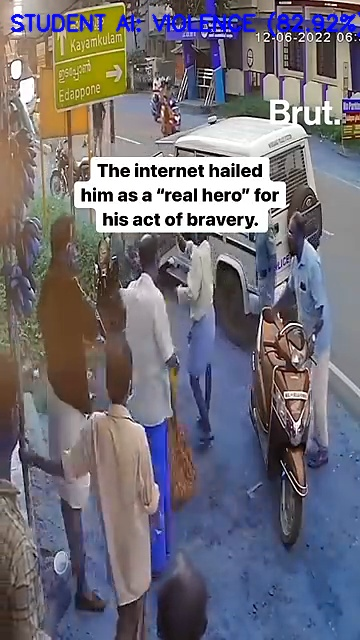


      FINAL ANALYSIS
File: This Kerala policeman’s bravery went viral on the internet as he subdued a man wielding a machete.mp4
Total Segments Analyzed: 44
Violent Segments: 22


In [38]:
import cv2
import torch
import numpy as np
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
from IPython.display import display, clear_output
import time
import os

# --- Configuration ---
# Path to your 22MB distilled student model
STUDENT_MODEL_PATH = os.path.expanduser("/media/rajendraprasath-m/New Volume/Projects/Final Year Project/Model/final_student_model")
VIDEO_PATH = os.path.expanduser("/media/rajendraprasath-m/New Volume/Projects/Final Year Project/Data/Video/EDA/Weapon Used Video/This Kerala policeman’s bravery went viral on the internet as he subdued a man wielding a machete.mp4")

# 1. Load Student Model and Processor
print("[INFO] Loading Student Model (DeiT-Tiny)...")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Load processor and ensure model config is read correctly
processor = AutoImageProcessor.from_pretrained(STUDENT_MODEL_PATH)
model = AutoModelForImageClassification.from_pretrained(STUDENT_MODEL_PATH).to(device)
model.eval()

# FIX: Force id2label keys to be integers (sometimes JSON saves them as strings)
id2label = {int(k): v for k, v in model.config.id2label.items()}

# Identify the violence label string for comparison
violence_label = next((n for n in id2label.values() if "viol" in n.lower() and "non" not in n.lower()), "Violence")
print(f"[INFO] Model loaded. Target class identified as: {violence_label}")

# 2. Prediction Loop
vs = cv2.VideoCapture(VIDEO_PATH)
fps = vs.get(cv2.CAP_PROP_FPS) or 30
frame_delay = 1 / fps

violence_count = 0
total_frames_processed = 0

# Initialize default values for display
label = "Initializing..."
score = 0.0

try:
    while True:
        ret, frame = vs.read()
        if not ret: 
            break
        
        # Predict every 1 second for performance
        if total_frames_processed % int(fps) == 0:
            # Prepare image for AI
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_image = Image.fromarray(img_rgb)
            inputs = processor(images=pil_image, return_tensors="pt").to(device)
            
            with torch.no_grad():
                outputs = model(**inputs)
                probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
                conf, pred_idx = torch.max(probs, dim=-1)

            # --- THE FIX: No int() or split() needed here ---
            # pred_idx.item() is 0 or 1. id2label[idx] gives "Violence" or "NonViolence"
            label = id2label[pred_idx.item()] 
            score = conf.item()
            
            # Increment violence counter if detected
            if label == violence_label:
                violence_count += 1

        total_frames_processed += 1
        
        # --- UI Overlay ---
        color = (0, 0, 255) if label == violence_label else (0, 255, 0)
        # Use upper() for a professional look
        cv2.putText(frame, f"STUDENT AI: {label.upper()} ({score:.2%})", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # --- Inline Display ---
        _, img_buffer = cv2.imencode(".jpeg", frame)
        clear_output(wait=True)
        # Display the frame and current stats
        print(f"🎬 Processing: {os.path.basename(VIDEO_PATH)}")
        print(f"📊 Violence detected in {violence_count} segments so far.")
        display(Image.fromarray(cv2.imdecode(img_buffer, cv2.IMREAD_COLOR)))
        
        # Keep playback speed realistic
        time.sleep(frame_delay * 0.5) 

except KeyboardInterrupt:
    print("\n[INFO] Stopped by user.")
finally:
    vs.release()
    print("\n" + "="*30)
    print("      FINAL ANALYSIS")
    print("="*30)
    print(f"File: {os.path.basename(VIDEO_PATH)}")
    print(f"Total Segments Analyzed: {violence_count + (total_frames_processed // int(fps))}")
    print(f"Violent Segments: {violence_count}")
    print("="*30)

In [ ]:
import torch.nn.utils.prune as prune

# Apply 20% unstructured pruning to the linear layers of the student
for name, module in student_model.named_modules():
    if isinstance(module, torch.nn.Linear):
        prune.l1_unstructured(module, name='weight', amount=0.2)
        prune.remove(module, 'weight') # Make the pruning permanent

# Save the final pruned model
torch.save(student_model.state_dict(), os.path.join(OPTIMIZED_DIR, "pruned_tiny_vit.pt"))
print("[SUCCESS] Model pruned by 20% and saved.")